# _Titanics Analysis_

## About this file 

The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone on board, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, we ask you to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).

### Lets Start Analysis

In [13]:
import pandas as pd
import numpy as py
import matplotlib.pyplot as plt

In [4]:
# extracting data from CSV file
df = pd.read_csv("C:\\Users\\FAIZAN COMPUTER\\Videos\\Jawaria's Folder\\Titanic-Dataset.csv")

In [8]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [9]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Replacing all blanks cells

In [10]:
#Removing and replacing all the null values from the AGE Cabin and Embarked columns
df["Age"] = df['Age'].fillna(0)
df['Age'] =df['Age'].astype('int')
df['Cabin'] = df['Cabin'].fillna('N/A')
df['Embarked'] =df['Embarked'].fillna(0)

In [11]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [68]:
#Finding full info about the file including their null values and their data types. 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    int64  
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(1), int64(6), object(5)
memory usage: 83.7+ KB


In [70]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,23.783389,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,17.597344,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,6.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,24.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [71]:
# Calculting rows and columns of the file with Shape function
df.shape

(891, 12)

## Survived %
Whether Survived or not: 0 = No, 1 = Yes

In [73]:
# In first line all the values of the Survived column will be counted.
# In second line percentage of all the counted values will be calculated.
# In third line new data frame named (survived_percentage ) will be created and count and percentage will be added to it. 
# then we will call the variable.
count = df['Survived'].value_counts()
percentage = df['Survived'].value_counts(normalize = True)*100
survived_percentage = pd.DataFrame({'Counts': count , 'Percentage%' : percentage})
survived_percentage

,Counts,Percentage%
Survived,,
0,549,61.616162
1,342,38.383838


<Axes: xlabel='Survived'>

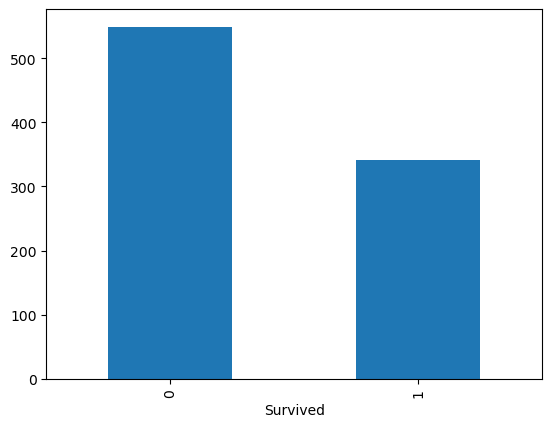

In [77]:
# Presenting the Survived Column into a graph
df['Survived'].value_counts().plot(kind = 'bar')

<Axes: ylabel='count'>

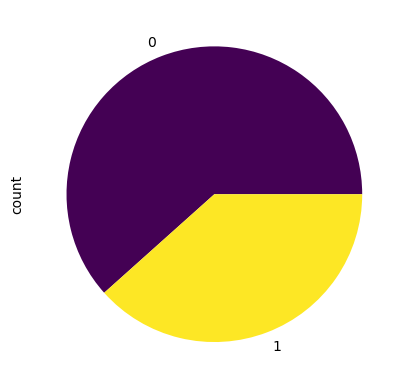

In [81]:
df['Survived'].value_counts().plot(kind = 'pie', colormap = 'viridis')

### Survived Summary
As per above Survived analysis about 61% of people with number 549 were not able to survived out of 891

## PClass Analysis
Ticket class: 1 = 1st, 2 = 2nd, 3 = 3rd

In [31]:
df['Pclass'].value_counts().sort_index()

Pclass
1    216
2    184
3    491
Name: count, dtype: int64

In [30]:
# In first line all the values of the Pclass column will be counted.
# In second line percentage of all the counted values will be calculated.
# In third line new data frame named (Pclass) will be created and count and percentage will be added to it. 
# then we will call the variable.
count = df['Pclass'].value_counts().sort_index()
percentage = df['Pclass'].value_counts(normalize = True)*100
Pclass = pd.DataFrame({'Counts': count,'Percentage':percentage})
Pclass

,Counts,Percentage
Pclass,,
1,216,24.242424
2,184,20.650954
3,491,55.106622


In [133]:
# In this cell first the data of the Survived column will be grouped on the bases on O & 1
# Then it will go to  Pclass where their will be group comparison of Survived and Pclass column
# After comparison all the vakues will be counted and sorted index wise
df.groupby('Survived')['Pclass'].value_counts().sort_index()

Survived  Pclass
0         1          80
          2          97
          3         372
1         1         136
          2          87
          3         119
Name: count, dtype: int64

<Axes: xlabel='Survived'>

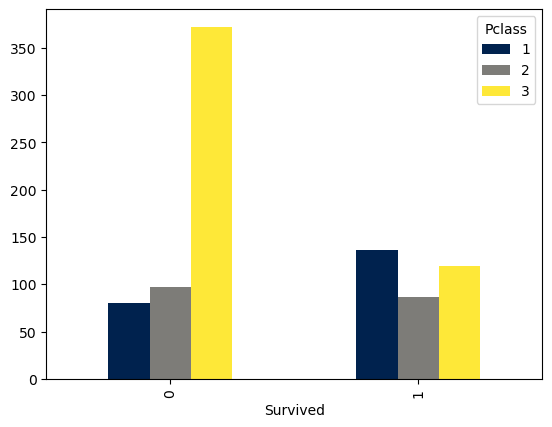

In [36]:
#  pd crosstab creates a frequency table between Survived and Pclass columns  from the given dataframe.
# .plot will make a chart either you will  mentioned will appear 
pd.crosstab(df['Survived'],df['Pclass']).plot(kind = 'bar',colormap = 'cividis')

<Axes: ylabel='count'>

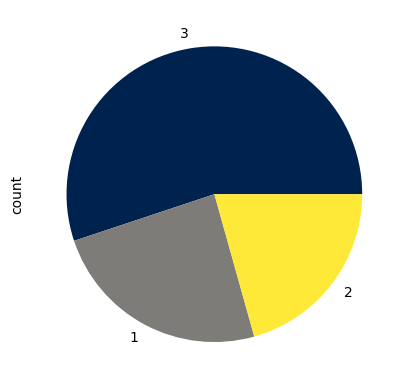

In [38]:
df['Pclass'].value_counts().plot(kind ='pie',colormap= 'cividis')

### Pclass Summary
491 passengers form 1st class, 216 from 2nd class and 184 passengers from 3rd class survived

## Parch Anlaysis


In [41]:
# Counting Parch values and sorting them index wise
df['Parch'].value_counts().sort_index()

Parch
0    678
1    118
2     80
3      5
4      4
5      5
6      1
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

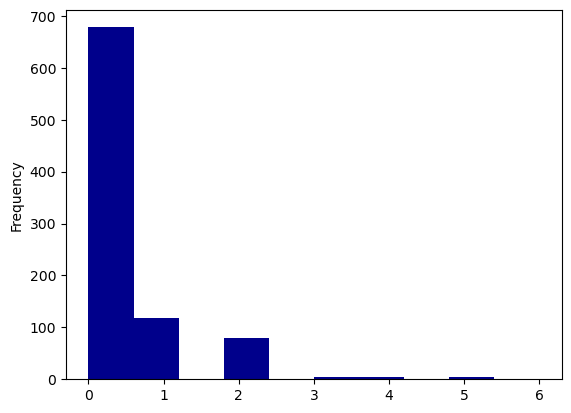

In [56]:
# Ploting the Parch Column into graph
df['Parch'].plot(kind='hist',color = 'Darkblue')

## Age Analysis with Survived ones


In [58]:
# Lets first check the minimum and maximum values of the age column to make the age_bins
df['Age'].min()

0

In [59]:
df['Age'].max()

80

In [ ]:
# lets create bins od age from the lowest to highest value and give them labels 
# then make a dataframe called fare_bins
# where pandas cut function will check all the values and keep storing them in their respected category of fare_bins 

In [104]:
bins = [0,21,41,61,80]
labels = ['0-20','21-40','41-60','61-80']
df['age_bins'] = pd.cut(df['Age'],bins=bins, labels=labels, include_lowest = False)
values_count = df['age_bins'].value_counts()
values_count

age_bins
21-40    368
0-20     197
41-60    123
61-80     19
Name: count, dtype: int64

In [114]:
# groupby finction will first chceck the survived column and group them in age_bin and values_count will count all the values & it will be index sorted  
df.groupby('Survived')['age_bins'].value_counts().sort_index()

Survived  age_bins
0         0-20        117
          21-40       218
          41-60        75
          61-80        14
1         0-20         80
          21-40       150
          41-60        48
          61-80         5
Name: count, dtype: int64

<Axes: xlabel='Survived'>

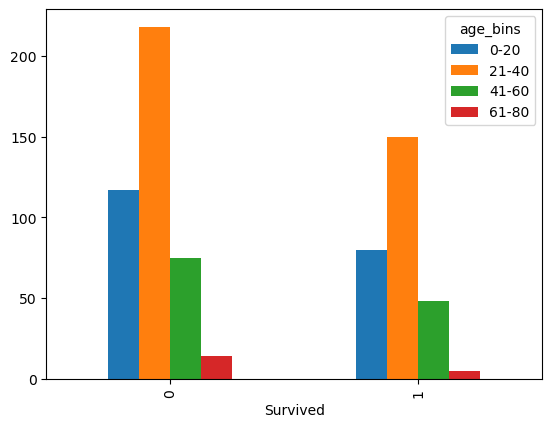

In [55]:
# pd.crosstab will create a table between Survived and age_bins from the given dataframe
# .plot
pd.crosstab(df['Survived'],df['age_bins']).plot(kind = 'bar')

### Survived Age comparison Analysis





1. Among passengers aged 0-20, 117 did not survive, and 80 survived.

2. Among passengers aged 21-40, 218 did not survive, and 150 survived.

3. Among passengers aged 41-60, 75 did not survive, and 48 survived.

4. Among passengers aged 61-80, 14 did not survive, and 5 survived.

### Survived Gender Analysis


In [116]:
# Goupby function will group values of Survived with Sex column by counting and sorting index wise 
df.groupby(['Survived'])["Sex"].value_counts().sort_index()


Survived  Sex   
0         female     81
          male      468
1         female    233
          male      109
Name: count, dtype: int64

<Axes: xlabel='Survived'>

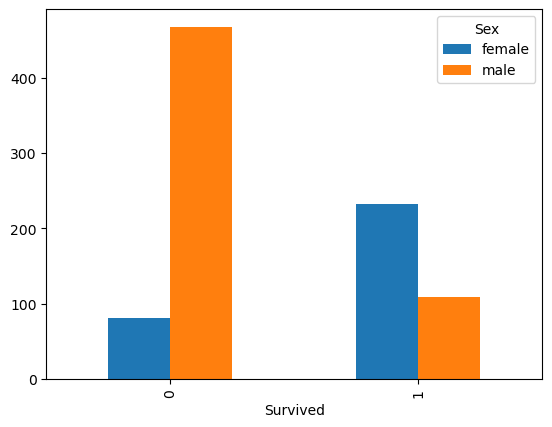

In [117]:
# Crosstab will make a table graph of Survived and Sex which are in same datafrrame
pd.crosstab(df['Survived'],df['Sex']).plot(kind = 'bar')

### Fare Analysis

In [141]:
df['Fare'].max()

512.3292

In [ ]:
# lets create bins of fare from the lowest to highest values and give them labels 
# then make a dataframe called fare_bins
# where pandas **cut** function will check all the values and keep storing them in their respected category of fare_bins 

In [152]:
bins = [0,101,201,301,401,501,601]
labels = ['0-100','101-200','201-300','301-400','401-500','501-600']
df['fare_bins']= pd.cut(df['Fare'],bins=bins,labels = labels,include_lowest = False)
values_count= df['fare_bins'].value_counts()
values_count

fare_bins
0-100      823
101-200     33
201-300     17
501-600      3
301-400      0
401-500      0
Name: count, dtype: int64

In [159]:
df.groupby('Survived')['fare_bins'].value_counts().sort_index()

Survived  fare_bins
0         0-100        521
          101-200        8
          201-300        6
          301-400        0
          401-500        0
          501-600        0
1         0-100        302
          101-200       25
          201-300       11
          301-400        0
          401-500        0
          501-600        3
Name: count, dtype: int64

<Axes: xlabel='Survived'>

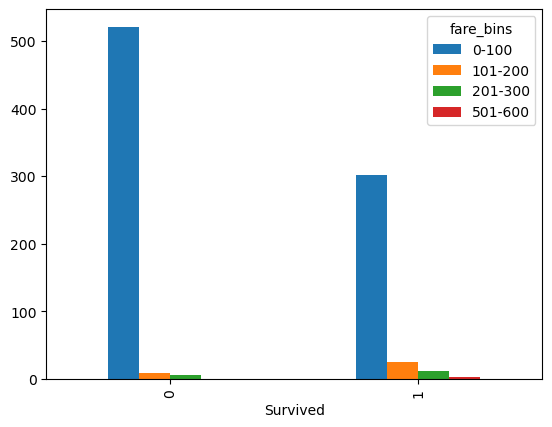

In [29]:
pd.crosstab(df['Survived'],df['fare_bins']).plot(kind='bar')

_____________________________________________________________________________________________________________________________________________________

---
##  Summary:
| Category | Insights |
|---|---|
| **Survival Rate** | 61.6% did NOT survive (549), 38.4% survived (342) |
| **Gender** | Females had far higher survival , 233 females vs 109 males survived |
| **Passenger Class** | Most passengers were in Class 3 (491). Class 1 passengers had better survival odds |
| **Age** | The 21–40 age group was the largest and had the most casualties |
| **Fare** | Majority (823 passengers) paid fares in the 0–100 range |
| **Parch** | Most passengers (678) traveled without parents or children |


_________________________________________________________________________________________________________________________